In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [17]:
df = pd.read_csv('solar_system.csv')

# Shape of dataframe
print(f'Dataframe Shape: {df.shape}')

# Number of rows and columns in dataframe 
print(f'\nRows: {df.shape[0]} \nColumns: {df.shape[1]}')

# First 5 and last 5 rows
print(f'\nFirst 5 rows:\n{df.head()}\n\nLast 5 rows:\n{df.tail()}')

# Column names
print(f'\nColumn Names: {df.columns}')

# Row names
print(f'\nRow Names:\n{df["Attribute"]}')

Dataframe Shape: (20, 11)

Rows: 20 
Columns: 11

First 5 rows:
                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  

Last 5 rows:
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons      

In [20]:
# Extract perihelion, aphelion, orbital period
perihelion = df.iloc[8, 1:].astype(float).values  # row 8, skip Attribute column
aphelion = df.iloc[9, 1:].astype(float).values    # row 9, skip "               "
orbital_period = df.iloc[10, 1:].astype(float).values  # row 10, skip "         "

- Perihelion: The planet's point of closest approach to the Sun.
- Aphelion: The planet's point of farthest distance from the Sun.
- Semi-major axis: Average distance between the planet and the sun.

In [43]:
# Calculate semi-major axis
semi_major_axis = (perihelion + aphelion) / 2  # in 10^6 km

# Create a new row as a Series
semi_major_row = pd.Series(
    ['Semi-major axis (10^6 km)'] + semi_major_axis.tolist(),
    index=df.columns  # match the existing DataFrame columns
)

# Concatenate with the original DataFrame
df_updated = pd.concat([df, semi_major_row.to_frame().T], ignore_index=True)  # .to_frame gives a column so we .T to transpose into a row
df_updated.tail()

,Attribute,Mercury,Venus,Earth,Moon,Mars,Jupiter,Saturn,Uranus,Neptune,Pluto
16,Surface Pressure (bars),0,92,1,0,0.01,Unknown,Unknown,Unknown,Unknown,0.00001
17,Number of Moons,0,0,1,0,2,95,274,28,16,5
18,Ring System?,No,No,No,No,No,Yes,Yes,Yes,Yes,No
19,Global Magnetic Field?,Yes,No,Yes,No,No,Yes,Yes,Yes,Yes,Unknown
20,Semi-major axis (10^6 km),57.9,108.2,149.6,0.3845,228.0,778.5,1432.05,2867.05,4515.0,5906.35


In [48]:
# Shape of new dataframe
print(f'Dataframe Shape: {df_updated.shape}')

# Number of rows and columns in dataframe
print(f'Rows: {df_updated.shape[0]}\nColumns: {df_updated.shape[1]}')

Dataframe Shape: (21, 11)
Rows: 21
Columns: 11


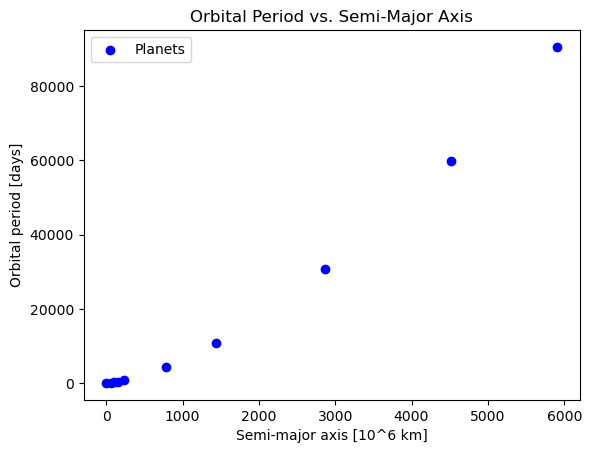

In [50]:
plt.figure()
plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets')
plt.xlabel('Semi-major axis [10^6 km]')
plt.ylabel('Orbital period [days]')
plt.title('Orbital Period vs. Semi-Major Axis')
plt.legend()
plt.show()

In [56]:
# Define the model
def keplers_third_law(a, m):
    return m * a ** 1.5

# Fit model
p0 = [1]  # initial guess for m
popt, pcov = curve_fit(keplers_third_law, semi_major_axis, orbital_period, p0=p0)
m_fit = popt[0]
print(f"Fitted model: T = {m_fit:.2f} * a^(3/2)")

Fitted model: T = 0.20 * a^(3/2)


In [57]:
# Reduced chi squared
residuals = orbital_period - keplers_third_law(semi_major_axis, m_fit)
chi2 = np.sum(residuals**2)
dof = len(semi_major_axis) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi-squared: {chi2_reduced:.2f}")

Reduced chi-squared: 41276.71


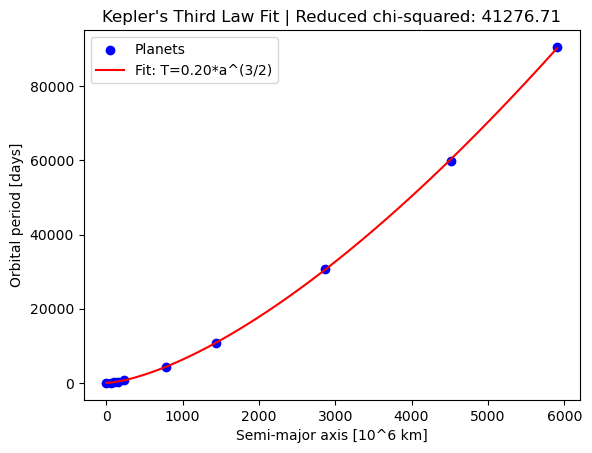

In [58]:
a_fit = np.linspace(min(semi_major_axis), max(semi_major_axis), 100)
T_fit = keplers_third_law(a_fit, m_fit)

plt.scatter(semi_major_axis, orbital_period, color='blue', label='Planets')
plt.plot(a_fit, T_fit, color='red', label=f'Fit: T={m_fit:.2f}*a^(3/2)')
plt.xlabel('Semi-major axis [10^6 km]')
plt.ylabel('Orbital period [days]')
plt.title(f'Kepler\'s Third Law Fit | Reduced chi-squared: {chi2_reduced:.2f}')
plt.legend()
plt.show()

In [59]:
df_updated.to_csv('kepler.csv', index=False)